In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import torch
from torch.utils.data import DataLoader, Dataset

pd.set_option('display.max_columns', None)

In [253]:
# reading data from source
train = pd.read_csv(r'..\\data\train_FD001.txt', sep=' ', header=None)
test = pd.read_csv(r'..\\data\test_FD001.txt', sep=' ', header=None)

# feature names as written in readme file
columns = (
    ["unit_number", "time_cycles"]
    + [f"operational_setting_{i}" for i in range(1, 4)]
    + [f"sensor_measurement_{i}" for i in range(1, 24)]
)

# renaming features
train.columns = columns
test.columns = columns

In [254]:
# drop null features (complete case analysis)
train = train.dropna(axis=1)
test = test.dropna(axis=1)

In [255]:
train.describe()

,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,sensor_measurement_6,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_10,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.3,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,0.001389,0.885092,0.070985,22.082880,0.0,0.267087,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.3,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.3,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.3,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.3,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.3,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [256]:
test.describe()

,unit_number,time_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_measurement_1,sensor_measurement_2,sensor_measurement_3,sensor_measurement_4,sensor_measurement_5,sensor_measurement_6,sensor_measurement_7,sensor_measurement_8,sensor_measurement_9,sensor_measurement_10,sensor_measurement_11,sensor_measurement_12,sensor_measurement_13,sensor_measurement_14,sensor_measurement_15,sensor_measurement_16,sensor_measurement_17,sensor_measurement_18,sensor_measurement_19,sensor_measurement_20,sensor_measurement_21
count,13096.000000,13096.000000,13096.000000,13096.000000,13096.0,13096.00,13096.000000,13096.000000,13096.000000,1.309600e+04,13096.000000,13096.000000,13096.000000,13096.000000,1.309600e+04,13096.000000,13096.000000,13096.000000,13096.000000,13096.000000,1.309600e+04,13096.000000,13096.0,13096.0,13096.000000,13096.000000
mean,51.543907,76.836515,-0.000011,0.000004,100.0,518.67,642.475088,1588.099204,1404.735362,1.462000e+01,21.609701,553.757523,2388.070964,9058.407363,1.300000e+00,47.416204,521.747724,2388.071025,8138.947817,8.425844,3.000000e-02,392.571625,2388.0,100.0,38.892502,23.335743
std,28.289423,53.057749,0.002203,0.000294,0.0,0.00,0.400899,5.003274,6.688309,1.776425e-15,0.001704,0.681286,0.057442,11.436261,2.220531e-16,0.195917,0.559627,0.056934,10.188605,0.029009,1.040874e-17,1.233577,0.0,0.0,0.141681,0.084120
min,1.000000,1.000000,-0.008200,-0.000600,100.0,518.67,641.130000,1569.040000,1384.390000,1.462000e+01,21.600000,550.880000,2387.890000,9024.530000,1.300000e+00,46.800000,519.380000,2387.890000,8108.500000,8.332800,3.000000e-02,389.000000,2388.0,100.0,38.310000,22.935400
25%,28.000000,33.000000,-0.001500,-0.000200,100.0,518.67,642.197500,1584.600000,1399.950000,1.462000e+01,21.610000,553.310000,2388.030000,9051.020000,1.300000e+00,47.270000,521.380000,2388.030000,8132.310000,8.405600,3.000000e-02,392.000000,2388.0,100.0,38.800000,23.281600
50%,52.000000,69.000000,-0.000000,-0.000000,100.0,518.67,642.460000,1587.990000,1404.440000,1.462000e+01,21.610000,553.800000,2388.070000,9057.320000,1.300000e+00,47.410000,521.780000,2388.070000,8138.390000,8.424900,3.000000e-02,393.000000,2388.0,100.0,38.900000,23.339200
75%,76.000000,113.000000,0.001500,0.000300,100.0,518.67,642.740000,1591.362500,1409.050000,1.462000e+01,21.610000,554.240000,2388.110000,9064.110000,1.300000e+00,47.540000,522.150000,2388.110000,8144.360000,8.444300,3.000000e-02,393.000000,2388.0,100.0,38.990000,23.393600
max,100.000000,303.000000,0.007800,0.000700,100.0,518.67,644.300000,1607.550000,1433.360000,1.462000e+01,21.610000,555.840000,2388.300000,9155.030000,1.300000e+00,48.260000,523.760000,2388.320000,8220.480000,8.541400,3.000000e-02,397.000000,2388.0,100.0,39.410000,23.641900


In [257]:
# dropping constant features
constant_features = [
    'operational_setting_3', 
    'sensor_measurement_1', 
    'sensor_measurement_5',
    'sensor_measurement_6',
    'sensor_measurement_10', 
    'sensor_measurement_16',
    'sensor_measurement_18',
    'sensor_measurement_19'
]

train = train.drop(constant_features, axis=1)
test = test.drop(constant_features, axis=1)

### Standard Linear RUL

In [258]:
# maximum cycle for each engine unit
max_cycles = train.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']

# Merge this maximum back into the main dataframe
train = train.merge(max_cycles, on='unit_number', how='left')

# Calculate the standard linear RUL
train['linear_rul'] = train['max_cycle'] - train['time_cycles']

# Drop the helper column
train.drop(columns=['max_cycle'], inplace=True)

### Piecewise Linear RUL

In [259]:
# industry standard cap for FD001 (typically 125 or 130)
R_max = 125 

# Apply the ceiling cap: if linear_rul > 125, force it to be 125
train['piecewise_rul'] = train['linear_rul'].clip(upper=R_max)

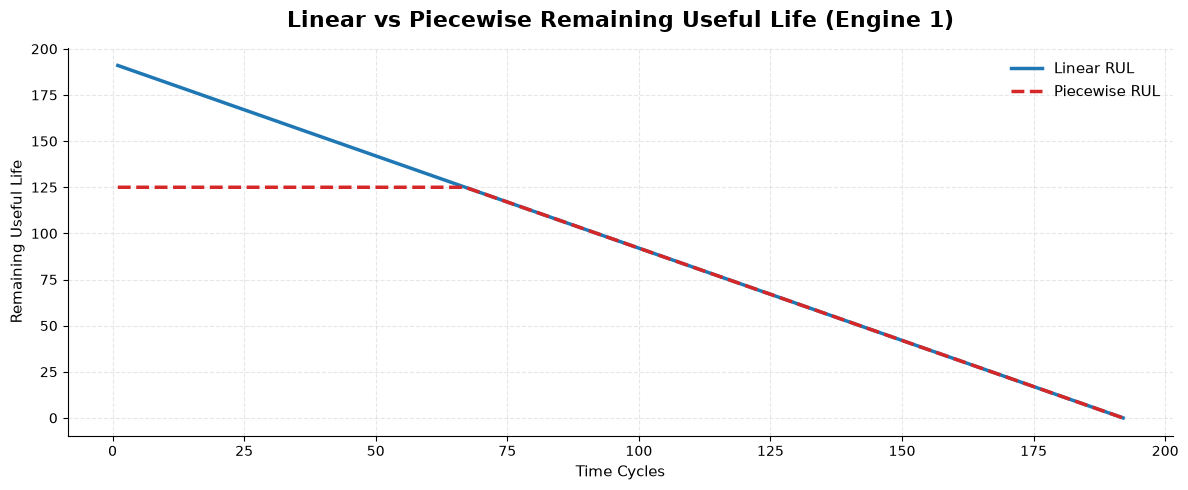

In [260]:
engine = train.loc[train["unit_number"] == 1].sort_values("time_cycles")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    engine["time_cycles"],
    engine["linear_rul"],
    label="Linear RUL",
    color="#1f77b4",
    linewidth=2.5,
)

ax.plot(
    engine["time_cycles"],
    engine["piecewise_rul"],
    label="Piecewise RUL",
    color="#d62728",
    linewidth=2.5,
    linestyle="--",
)

ax.set_title(
    "Linear vs Piecewise Remaining Useful Life (Engine 1)",
    fontsize=16,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel("Time Cycles", fontsize=11)
ax.set_ylabel("Remaining Useful Life", fontsize=11)

ax.grid(
    linestyle="--",
    alpha=0.3,
)

ax.legend(
    frameon=False,
    fontsize=11,
)

sns.despine()

plt.tight_layout()
plt.show()

### Robust Scaling

In [261]:
# features to scale
scale_cols = [
    'operational_setting_1',
    'operational_setting_2', 
    'sensor_measurement_2', 
    'sensor_measurement_3',
    'sensor_measurement_4', 
    'sensor_measurement_7',
    'sensor_measurement_8', 
    'sensor_measurement_9', 
    'sensor_measurement_11',
    'sensor_measurement_12', 
    'sensor_measurement_13',
    'sensor_measurement_14', 
    'sensor_measurement_15',
    'sensor_measurement_17', 
    'sensor_measurement_20',
    'sensor_measurement_21'
]

In [262]:
scaler = RobustScaler()
train[scale_cols] = scaler.fit_transform(train[scale_cols])
test[scale_cols] = scaler.fit_transform(test[scale_cols])

In [263]:
relevant_cols = [
    'operational_setting_1',
    'operational_setting_2', 
    'sensor_measurement_2', 
    'sensor_measurement_3',
    'sensor_measurement_4',
    'sensor_measurement_7', 
    'sensor_measurement_8', 
    'sensor_measurement_9', 
    'sensor_measurement_11',
    'sensor_measurement_12', 
    'sensor_measurement_13',
    'sensor_measurement_14', 
    'sensor_measurement_15', 
    'sensor_measurement_17',
    'sensor_measurement_20', 
    'sensor_measurement_21'
]

In [264]:
class TrainDataset(Dataset):
    def __init__(
        self,
        data: pd.DataFrame,
        feature_cols: list[str],
        target_col: str = "linear_rul",
        window_size: int = 30,
        stride: int = 1,
    ) -> None:

        super().__init__()

        self.window_size = window_size
        self.feature_cols = feature_cols
        self.target_col = target_col

        self.samples: list[tuple[np.ndarray, np.float32]] = []

        for _, engine_df in data.groupby("unit_number"):

            engine_df = engine_df.sort_values("time_cycles")

            X = engine_df[self.feature_cols].to_numpy(dtype=np.float32)
            y = engine_df[self.target_col].to_numpy(dtype=np.float32)

            n = len(engine_df)

            for start in range(0, n - self.window_size + 1, stride):

                end = start + self.window_size

                window = X[start:end]
                target = y[end - 1]

                self.samples.append((window, target))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx):

        window, target = self.samples[idx]

        return (
            torch.from_numpy(window),
            torch.tensor(target, dtype=torch.float32),
        )

train_dataset = TrainDataset(
    data=train,
    feature_cols=relevant_cols,
    target_col="piecewise_rul",
    window_size=30,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [265]:
class TestDataset(Dataset):
    def __init__(
        self,
        data: pd.DataFrame,
        feature_cols: list[str],
        window_size: int = 30,
    ) -> None:

        super().__init__()

        self.window_size = window_size
        self.feature_cols = feature_cols

        self.samples: list[np.ndarray] = []

        for _, engine_df in data.groupby("unit_number"):

            engine_df = engine_df.sort_values("time_cycles")

            X = engine_df[self.feature_cols].to_numpy(dtype=np.float32)

            window = X[-self.window_size:]

            self.samples.append(window)

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx):

        window = self.samples[idx]

        return torch.from_numpy(window)


# Dataset
test_dataset = TestDataset(
    data=test,
    feature_cols=relevant_cols,
    window_size=30,
)

# DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)

In [266]:
for X, y in train_loader:
    print(X)
    print(y)

    print(X.shape)
    print(y.shape)

    break

tensor([[[ 1.0333,  1.0000, -1.3037,  ...,  0.5000,  0.3200,  0.5752],
         [-0.4667, -0.6000, -0.2074,  ..., -1.0000,  0.7200,  0.1124],
         [ 0.7333,  0.2000,  0.1037,  ...,  1.0000, -0.4000, -0.3841],
         ...,
         [-0.6000, -1.0000,  0.6667,  ...,  0.5000, -0.7200,  0.6648],
         [ 1.0333, -0.2000,  0.3704,  ..., -0.5000, -0.2800,  0.1834],
         [-0.7333, -0.4000, -0.0889,  ..., -0.5000,  0.0000,  0.2545]],

        [[ 0.3000, -0.8000,  0.3407,  ...,  0.0000, -0.6400,  0.0648],
         [ 1.4333,  0.4000,  0.2074,  ...,  1.0000, -0.5600, -0.4483],
         [ 0.7000,  0.2000,  0.4889,  ..., -0.5000, -0.2000,  0.0131],
         ...,
         [ 1.0667, -1.0000,  0.6222,  ...,  1.5000, -1.6400, -1.0407],
         [ 0.2000,  0.4000,  1.5111,  ...,  0.5000, -0.2400, -0.9800],
         [ 0.2333,  0.8000,  1.0815,  ...,  1.5000, -0.7600, -1.0414]],

        [[-0.1667, -0.0000, -1.1259,  ...,  0.0000,  0.2000,  0.0531],
         [-0.7667,  0.0000, -0.0593,  ..., -0

In [267]:
for X in test_loader:
    print(X)

    print(X.shape)

    break

tensor([[[-0.9000, -0.6000, -1.3825,  ...,  0.0000,  0.6316,  0.4679],
         [ 0.1000,  0.2000,  0.0000,  ...,  0.0000,  0.9474,  0.6911],
         [ 1.4000,  0.0000, -0.0369,  ..., -2.0000,  0.5263,  0.3080],
         ...,
         [ 0.4667,  0.2000, -0.9401,  ..., -1.0000,  0.6316,  0.2045],
         [-0.8333,  0.8000,  0.6083,  ..., -2.0000,  1.0000,  0.6045],
         [-0.2000,  0.8000,  0.2212,  ...,  0.0000, -0.4737,  0.1429]],

        [[ 1.3000,  0.8000,  0.4793,  ...,  0.0000, -0.6842, -0.8009],
         [-1.2667, -0.6000, -0.2581,  ...,  1.0000, -0.0526,  0.3964],
         [ 0.1667,  0.6000, -0.0369,  ...,  0.0000, -0.1053, -0.8188],
         ...,
         [-0.9667, -0.8000,  0.7189,  ..., -1.0000, -0.1053, -0.3812],
         [ 0.3667, -0.2000,  0.3318,  ..., -1.0000,  0.4737, -0.4232],
         [ 0.6000, -0.2000,  0.1659,  ..., -2.0000, -0.4737, -0.6911]],

        [[-2.4333, -0.6000,  0.7373,  ..., -1.0000, -0.4211, -0.8348],
         [-0.5000,  0.4000,  0.0000,  ...,  1